# Training-data exploration

This notebook uses only the **fitting partition** of the official NASA C-MAPSS training files. Validation and official test trajectories are excluded. It is descriptive, not part of model selection or a prerequisite for the application. Source: NASA Ames Prognostics Data Repository, Saxena and Goebel (2008).


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from engine_health.data import SUBSETS, load_table
root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
splits = json.loads((root / "protocols/study_v1/splits.json").read_text())
frames = {}
for subset in SUBSETS:
    full = load_table(root / "data", subset, "train")
    frames[subset] = full.loc[full.unit.isin(splits["subsets"][subset]["train"])].copy()
    frame = frames[subset]
    print(f"{subset}: {frame.unit.nunique()} fitting engines, {len(frame):,} cycles")


FD001: 80 fitting engines, 16,347 cycles
FD002: 208 fitting engines, 43,077 cycles
FD003: 80 fitting engines, 19,647 cycles
FD004: 199 fitting engines, 49,183 cycles


## Unequal trajectory lengths

Longer-lived engines create more windows. This motivates giving each engine equal total sample weight; a random window split would also leak strongly overlapping histories.


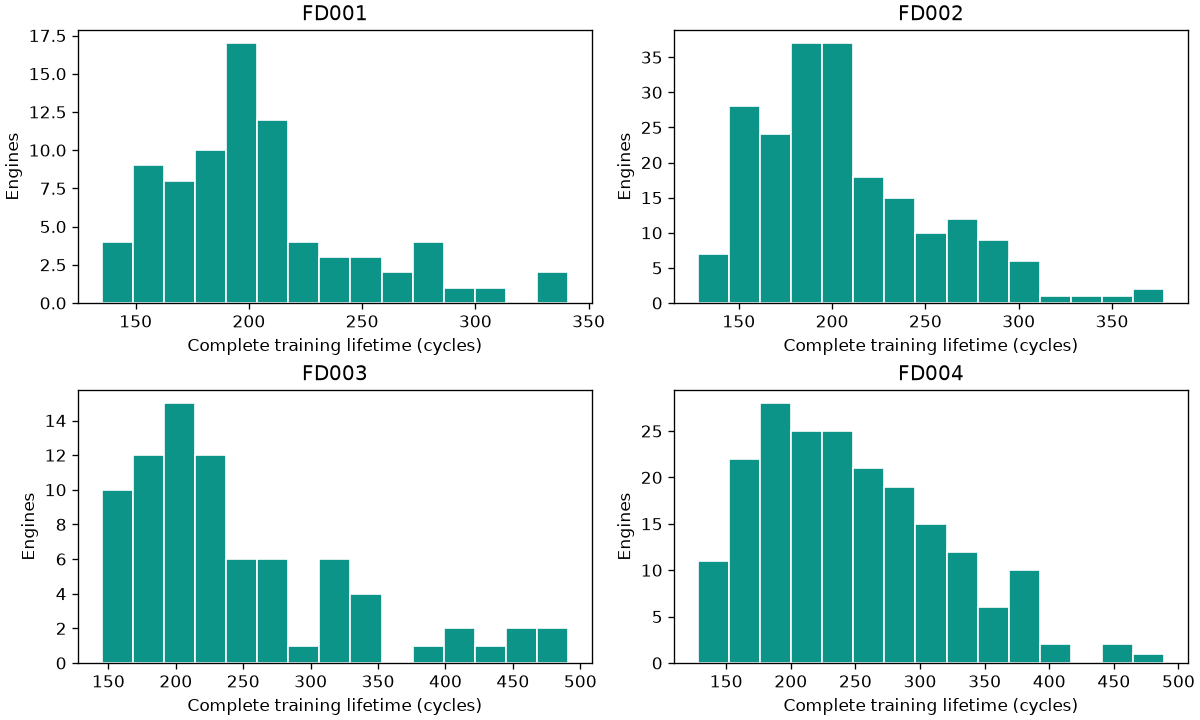

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), layout="constrained")
for ax, (subset, frame) in zip(axes.flat, frames.items()):
    lifetimes = frame.groupby("unit").cycle.max()
    ax.hist(lifetimes, bins=15, color="#0d9488", edgecolor="white")
    ax.set(title=subset, xlabel="Complete training lifetime (cycles)", ylabel="Engines")
plt.show()


## Operating settings

FD002 and FD004 contain several operating regimes. Condition normalization is fitted on these training settings only. A setting cluster is an operating condition, not an engine-fault label.


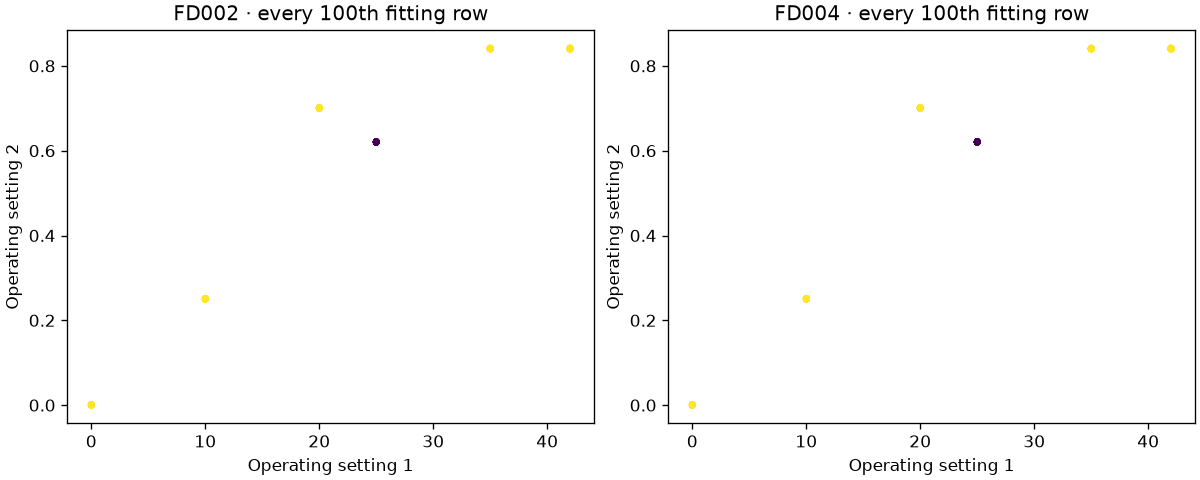

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
for ax, subset in zip(axes, ("FD002", "FD004")):
    sample = frames[subset].iloc[::100]
    ax.scatter(sample.setting_1, sample.setting_2, c=sample.setting_3, cmap="viridis", s=9, alpha=.6)
    ax.set(title=subset + " · every 100th fitting row", xlabel="Operating setting 1", ylabel="Operating setting 2")
plt.show()


## Checks rather than visual assumptions

The automated data audit checks all files and motor IDs. A plausible histogram does not establish integrity, prevent temporal leakage or demonstrate model accuracy. See `docs/results/DATA_AUDIT.json`, the fixed splits and the causality tests. No test-performance conclusions are drawn here.
